<a href="https://colab.research.google.com/github/fddxxueyj/Summer-Research-HKUST-OCES/blob/main/FNO_offline(NO).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np
import xarray as xr
import glob
from sklearn.model_selection import train_test_split
import sys
import math
import matplotlib.pyplot as plt

import optax
import torch

In [ ]:
ds=xr.open_dataset('/content/drive/MyDrive/summer/train.nc')

/tmp/ipykernel_1000/705896424.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds=xr.open_dataset('/content/drive/MyDrive/summer/train.nc')


In [ ]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:              (run: 300, time: 86, lev: 2, y: 64, x: 64)
Coordinates:
  * time                 (time) timedelta64[ns] 688B 41 days 16:00:00.0000288...
  * lev                  (lev) int32 8B 1 2
  * y                    (y) float64 512B 7.812e+03 2.344e+04 ... 9.922e+05
  * x                    (x) float64 512B 7.812e+03 2.344e+04 ... 9.922e+05
Dimensions without coordinates: run
Data variables:
    psi                  (run, time, lev, y, x) float32 845MB ...
    q                    (run, time, lev, y, x) float32 845MB ...
    q_forcing_advection  (run, time, lev, y, x) float32 845MB ...
Attributes: (12/24)
    pyqg:L:          1000000.0
    pyqg:M:          65536
    pyqg:W:          1000000.0
    pyqg:beta:       1.5e-11
    pyqg:del2:       0.8
    pyqg:delta:      0.25
    ...              ...
    pyqg:tc:         86400
    pyqg:tmax:       311040000
    pyqg:twrite:     1000.0
    pyqg_params:     {'nx': 256, 'dt': 3600, 'tmax': 311040000, 'tavestart': ...
    reference:       https://pyqg.readthedocs.io/en/latest/index.html
    title:           pyqg: Python Quasigeostrophic Model

In [ ]:
q_scal= 1e6 # one input
#q_scal= 1e9 # two inputs
sq_scal = 1e13
sq_scal_invert = 1e-13

psi_scal=1e-2

In [ ]:
ds["q_forcing_advection2"] = ds["q_forcing_advection"]*sq_scal
ds["q"] = ds["q"]*q_scal

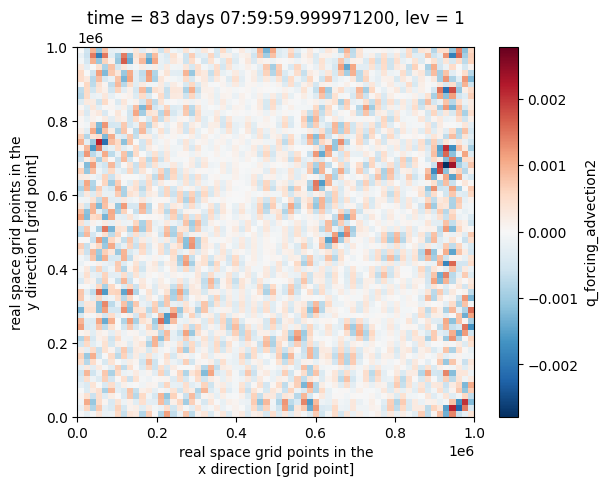

In [ ]:
ds["q_forcing_advection2"].isel(run=30,time=1,lev=0).plot()

In [ ]:
train_size = 295

layer_c=1
train_ds = ds.isel(run=slice(0,train_size), lev=layer_c).load()

In [ ]:
random_seed = 1
train_ratio = 0.8

train_ds1 = train_ds.isel(time=slice(20, None)).stack(z=("run", "time"))
train_ds2 = train_ds.stack(z=("run", "time"))

xdata = np.moveaxis(train_ds1.q.values, -1, 0)[:, np.newaxis]
ydata = np.moveaxis(train_ds1.q_forcing_advection2.values, -1, 0)[:, np.newaxis]

# Randomly select indices for training from train_ds1
num_train_ds1 = len(xdata)
np.random.seed(random_seed)
all_train_ds1_indices = np.arange(num_train_ds1)
train_indices = np.random.choice(all_train_ds1_indices, size=int(num_train_ds1 * train_ratio), replace=False)

# Extract training data
xTrain = xdata[train_indices]
yTrain = ydata[train_indices]

# The remaining data from train_ds1 forms part of the validation set
train_idx_set = set(train_indices)
val_indices_in_ds1 = [i for i in range(num_train_ds1) if i not in train_idx_set]

xVal_part2 = xdata[val_indices_in_ds1]
yVal_part2 = ydata[val_indices_in_ds1]

# The data from train_ds2 that is not in train_ds1 (time < 20) forms the rest of the validation set
val_ds_part1 = train_ds.isel(time=slice(0, 20)).stack(z=("run", "time"))
xVal_part1 = np.moveaxis(val_ds_part1.q.values, -1, 0)[:, np.newaxis]
yVal_part1 = np.moveaxis(val_ds_part1.q_forcing_advection2.values, -1, 0)[:, np.newaxis]

# Combine and optionally shuffle validation set
xVal = np.concatenate([xVal_part1, xVal_part2], axis=0)
yVal = np.concatenate([yVal_part1, yVal_part2], axis=0)

val_shuffle_idx = np.random.permutation(len(xVal))
xVal = xVal[val_shuffle_idx]
yVal = yVal[val_shuffle_idx]


In [ ]:
batchsize=64
dataset = torch.utils.data.TensorDataset(torch.from_numpy(xTrain).float(),torch.from_numpy(yTrain).float())
train_loader=torch.utils.data.DataLoader(dataset , batch_size=batchsize, shuffle=True, num_workers=2)
dataset = torch.utils.data.TensorDataset(torch.from_numpy(xVal).float(),torch.from_numpy(yVal).float())
val_loader=torch.utils.data.DataLoader(dataset , batch_size=batchsize, shuffle=True, num_workers=2)

In [ ]:
!pip install neuraloperator tensorly tensorly-torch

In [ ]:
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.layers.padding import DomainPadding
from neuralop.utils import count_model_params

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = FNO(
    n_modes=(48, 48),
    n_layers=6,
    in_channels=1,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
    norm='instance_norm'
).to(device)

print(f"Model parameters: {count_model_params(model)}")

Model parameters: 2076313


In [ ]:
import torch.optim as optim
from neuralop import LpLoss
import numpy as np

criterion = LpLoss(d=2, p=2)
optimizer = optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min=1e-6)
epochs = 50

total_trainloss = []
total_valloss = []
total_valcorr = []

# Early stopping parameters, not necessary
patience = 50
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):

    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)
    total_trainloss.append(train_loss)

    model.eval()
    val_loss = 0.0
    val_corr = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * x_batch.size(0)

            preds_np = outputs.cpu().numpy().flatten()
            truths_np = y_batch.cpu().numpy().flatten()
            batch_corr = np.corrcoef(preds_np, truths_np)[0, 1]
            val_corr += batch_corr * x_batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_corr /= len(val_loader.dataset)

    total_valloss.append(val_loss)
    total_valcorr.append(val_corr)

    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss (L2): {train_loss:.4f} | Val Loss (L2): {val_loss:.4f} | Val Corr: {val_corr:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}!")
        break

Epoch [01/50] | Train Loss (L2): 42.0732 | Val Loss (L2): 944200.9773 | Val Corr: 0.8282
Epoch [02/50] | Train Loss (L2): 32.1301 | Val Loss (L2): 567465.1975 | Val Corr: 0.8651
Epoch [03/50] | Train Loss (L2): 30.2000 | Val Loss (L2): 586159.1142 | Val Corr: 0.8733
Epoch [04/50] | Train Loss (L2): 29.1671 | Val Loss (L2): 777369.9909 | Val Corr: 0.8768
Epoch [05/50] | Train Loss (L2): 28.5190 | Val Loss (L2): 759623.2273 | Val Corr: 0.8772
Epoch [06/50] | Train Loss (L2): 28.0269 | Val Loss (L2): 770691.5051 | Val Corr: 0.8846
Epoch [07/50] | Train Loss (L2): 27.7427 | Val Loss (L2): 774109.7323 | Val Corr: 0.8824
Epoch [08/50] | Train Loss (L2): 27.3379 | Val Loss (L2): 805521.2435 | Val Corr: 0.8870
Epoch [09/50] | Train Loss (L2): 27.1408 | Val Loss (L2): 819490.6783 | Val Corr: 0.8887
Epoch [10/50] | Train Loss (L2): 26.9176 | Val Loss (L2): 820239.7733 | Val Corr: 0.8873
Epoch [11/50] | Train Loss (L2): 26.7346 | Val Loss (L2): 856218.9339 | Val Corr: 0.8907
Epoch [12/50] | Train

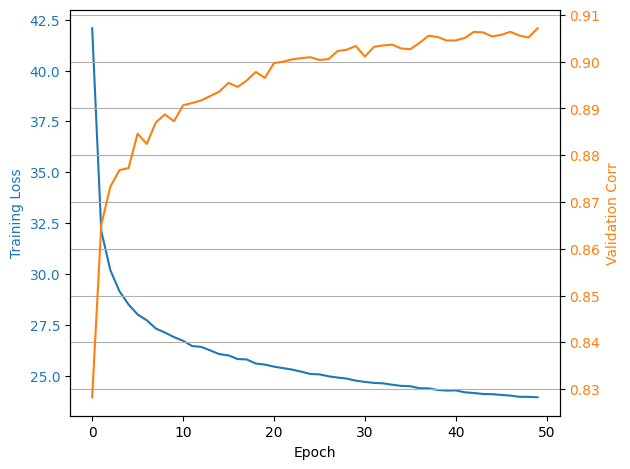

In [ ]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(total_trainloss, color=color, label='training loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'tab:orange'
ax2.set_ylabel('Validation Corr', color=color)
ax2.plot(total_valcorr, color=color, label='validation corr')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.grid()
plt.show()

In [ ]:
test_d = ds.isel(run=-1,time=slice(-10,None),lev=layer_c).load()

xTest=test_d.q.values[:,np.newaxis]
yTest = test_d.q_forcing_advection.values[:,np.newaxis]

index = 1

with torch.no_grad():

  x_test = torch.tensor(xTest[index:index+1, :, :, :], dtype=torch.float32).to(device)
  outputs_test = model(x_test)


Shape of yTrain_mean: (1, 64, 64)


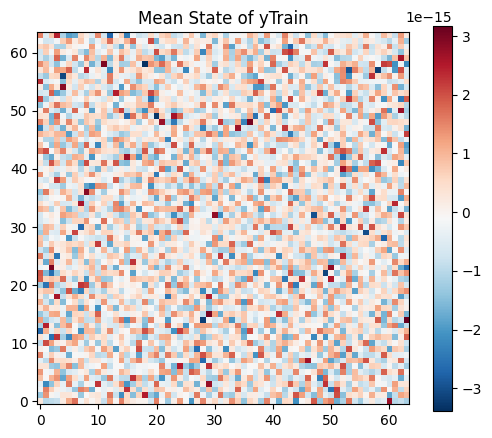

In [ ]:
# the coefficient of determination

# the mean state of the training data
yTrain_mean = np.mean(yTrain, axis=0)*sq_scal_invert
print(f"Shape of yTrain_mean: {yTrain_mean.shape}")

# plot the mean state
plt.figure(figsize=(6, 5))
im = plt.imshow(yTrain_mean[0], cmap='RdBu_r', origin='lower')
plt.colorbar(im)
plt.title('Mean State of yTrain')
plt.show()

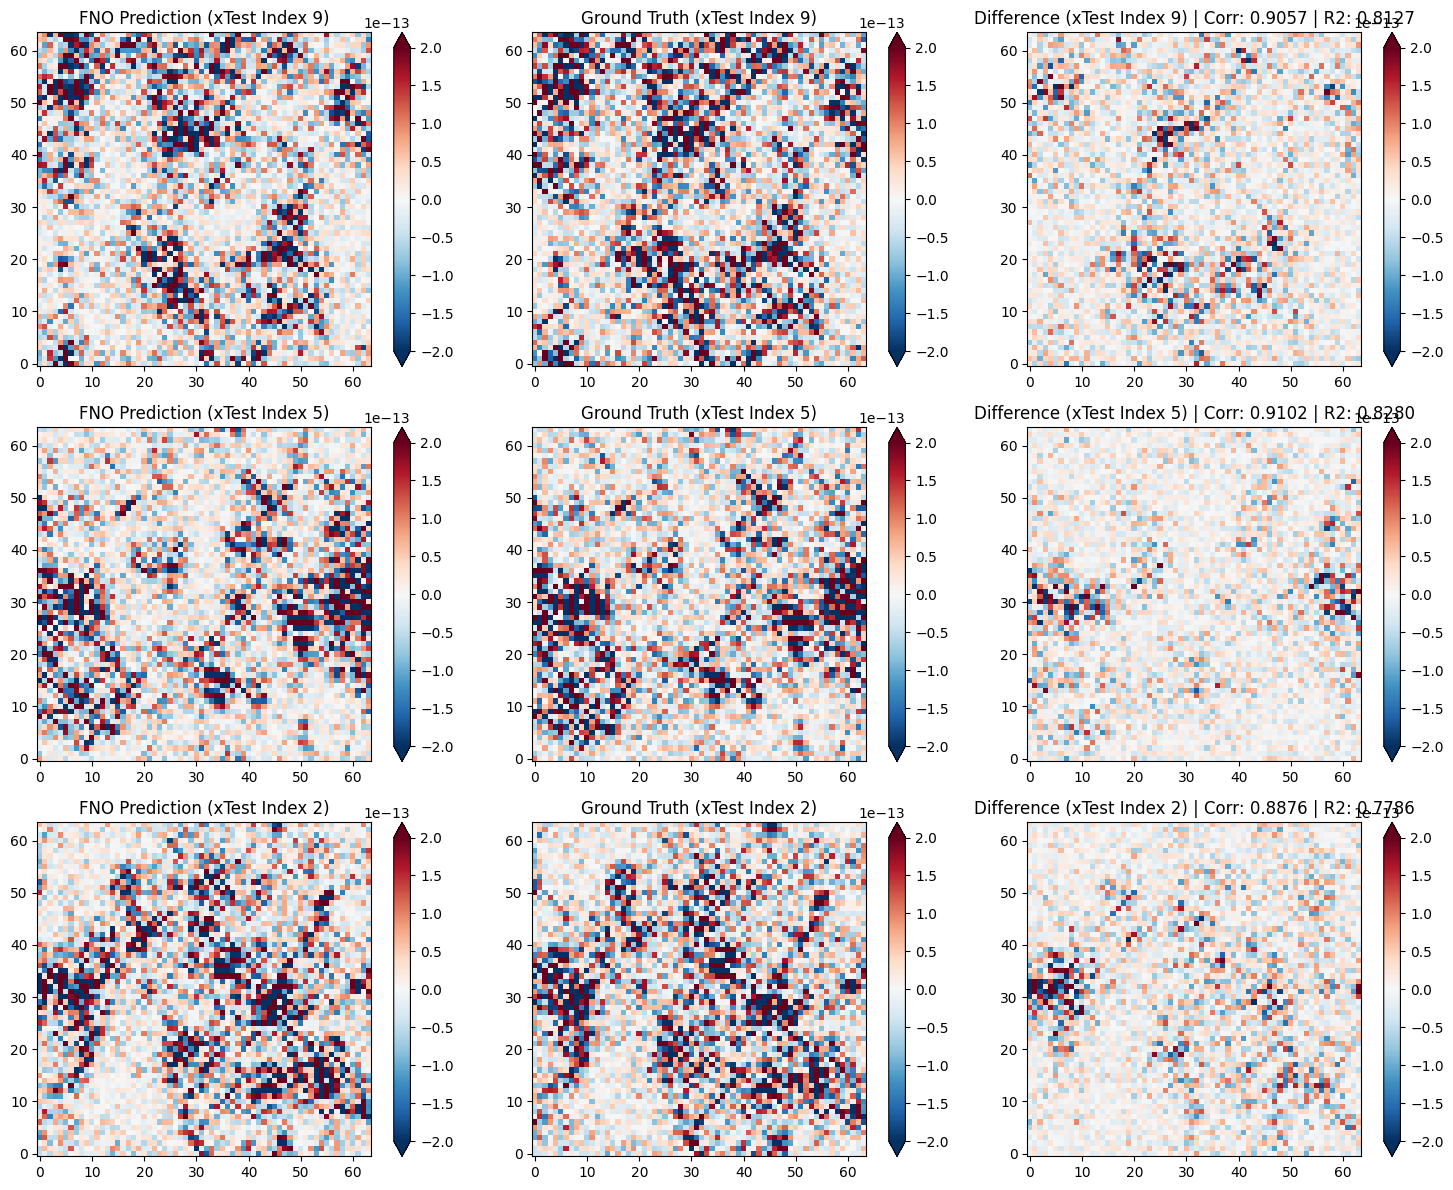

Average correlation coefficient over 3 random xTest samples: 0.9012
Average R2 over 3 random xTest samples: 0.8065


In [ ]:
import random

num_test_samples = xTest.shape[0]
random_indices = random.sample(range(num_test_samples), 3)

# Create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
correlations = []
r2_scores = []

if layer_c == 0:
  scale = 2e-11
else:
  scale = 2e-13


y_train_mean_2d = yTrain_mean.squeeze()

for row, idx in enumerate(random_indices):
    with torch.no_grad():
        x_test = torch.tensor(xTest[idx:idx+1, :, :, :], dtype=torch.float32).to(device)
        # x_test_padded = domain_padding.pad(x_test)
        outputs_test_random = model(x_test)
        # outputs_test_random = domain_padding.unpad(out_test_padded)

    pred_plot = (outputs_test_random / sq_scal).cpu().squeeze().numpy()
    true_plot = yTest[idx, 0]
    diff_plot = pred_plot - true_plot

    correlation = np.corrcoef(pred_plot.flatten(), true_plot.flatten())[0, 1]
    correlations.append(correlation)

    ss_res = np.sum((true_plot - pred_plot) ** 2)
    ss_tot = np.sum((true_plot - y_train_mean_2d) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    r2_scores.append(r2)

    im0 = axes[row, 0].imshow(pred_plot, cmap='RdBu_r', origin='lower',
                         vmin=-scale, vmax=scale)
    axes[row, 0].set_title(f"FNO Prediction (xTest Index {idx})")
    fig.colorbar(im0, ax=axes[row, 0], extend='both')

    im1 = axes[row, 1].imshow(true_plot, cmap='RdBu_r', origin='lower',
                         vmin=-scale, vmax=scale)
    axes[row, 1].set_title(f"Ground Truth (xTest Index {idx})")
    fig.colorbar(im1, ax=axes[row, 1], extend='both')

    im2 = axes[row, 2].imshow(diff_plot, cmap='RdBu_r', origin='lower',
                         vmin=-scale, vmax=scale)
    axes[row, 2].set_title(f"Difference (xTest Index {idx}) | Corr: {correlation:.4f} | R2: {r2:.4f}")
    fig.colorbar(im2, ax=axes[row, 2], extend='both')

plt.tight_layout()
plt.show()

avg_correlation = np.mean(correlations)
avg_r2 = np.mean(r2_scores)

print(f"Average correlation coefficient over 3 random xTest samples: {avg_correlation:.4f}")
print(f"Average R2 over 3 random xTest samples: {avg_r2:.4f}")

In [ ]:
# total_trainloss.pop()
# print(f"Size of total_trainloss: {len(total_trainloss)}")
# print(f"Size of total_valloss: {len(total_valloss)}")
# print(f"Size of total_valcorr: {len(total_valcorr)}")


In [ ]:
import os
from datetime import datetime


# date
date_str = datetime.now().strftime("%Y%m%d")
version = "v1"
base_name = f"{date_str}{version}_layer{layer_c}"

# root
models_dir = "/content/drive/MyDrive/summer/models"
results_dir = "/content/drive/MyDrive/summer/results"

os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

model_save_path = os.path.join(models_dir, f"{base_name}.pth")
torch.save(model.cpu().state_dict(), model_save_path)
model.to(device)
print(f"model ok: {model_save_path}")

loss_save_path = os.path.join(results_dir, f"{base_name}_loss.txt")
loss_data = np.column_stack((total_trainloss, total_valloss, total_valcorr))
np.savetxt(loss_save_path, loss_data, header="Train_Loss Validation_Loss Validation_Corr", fmt="%.6f", comments='')
print(f"loss ok: {loss_save_path}")

plot_save_path = os.path.join(results_dir, f"{base_name}_plot.png")
try:
    fig.savefig(plot_save_path, bbox_inches='tight', dpi=300)
    print(f"figure ok: {plot_save_path}")
except NameError:
    print("no fig")

model ok: /content/drive/MyDrive/summer/models/20260621v1_layer1.pth
loss ok: /content/drive/MyDrive/summer/results/20260621v1_layer1_loss.txt
figure ok: /content/drive/MyDrive/summer/results/20260621v1_layer1_plot.png


Found 6 complex spectral weight tensors.


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


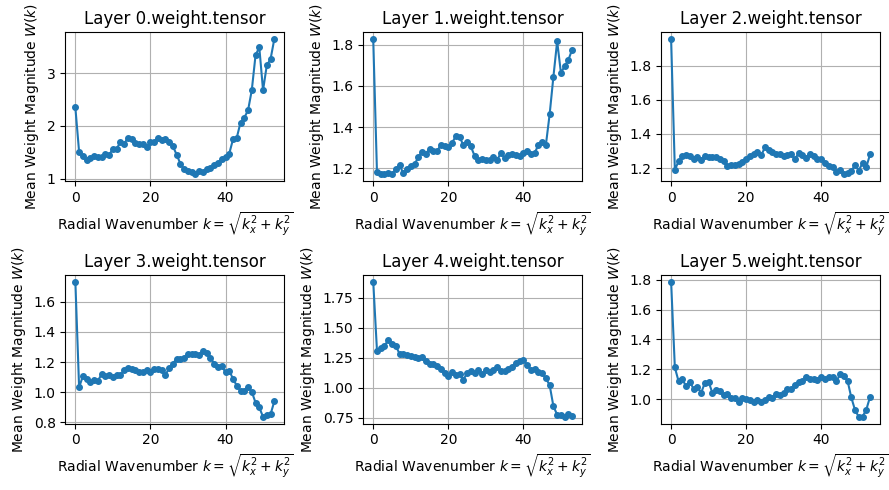

In [ ]:
import math

layer_mags = []

# Extract spectral weights from the model's parameters
# In NeuralOperator, the FNO blocks contain the spectral convolutions
for name, param in model.named_parameters():
    if 'convs' in name and param.is_complex():
        # Average the magnitude over input and output channels
        mag = torch.mean(torch.abs(param), dim=(0, 1)).cpu().detach().numpy()
        layer_mags.append((name, mag))

print(f"Found {len(layer_mags)} complex spectral weight tensors.")

# Plotting the spectral weights radially
if layer_mags:
    num_plots = len(layer_mags)
    cols = 3
    rows = math.ceil(num_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (name, mag) in enumerate(layer_mags):
        ax = axes[i]

        # Create kx and ky grids based on the mode dimensions
        mode1, mode2 = mag.shape
        kx = np.arange(mode1)
        ky = np.arange(mode2)
        KX, KY = np.meshgrid(kx, ky, indexing='ij')

        # Calculate radial wavenumber k = sqrt(kx^2 + ky^2)
        K = np.sqrt(KX**2 + KY**2)

        K_flat = K.flatten()
        mag_flat = mag.flatten()

        # Bin the magnitudes by rounded integer radial wavenumber to compute W(k)
        K_int = np.round(K_flat).astype(int)
        unique_k = np.unique(K_int)
        W_k = np.array([np.mean(mag_flat[K_int == k]) for k in unique_k])

        ax.plot(unique_k, W_k, marker='o', markersize=4, linestyle='-')
        ax.set_title(name.replace('fno_blocks.convs.', 'Layer '))
        ax.set_xlabel(r'Radial Wavenumber $k = \sqrt{k_x^2 + k_y^2}$')
        ax.set_ylabel('Mean Weight Magnitude $W(k)$')
        ax.grid(True)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/summer/results/spectral_weights.png', bbox_inches='tight', dpi=300)
    plt.show()
